# 05b Calibrate Watershed

Wflow Readiness: validate the Wflow discharge **response** against observed USGS instantaneous (IV) records for **historical validation events** (design rows whose rainfall analog runs at ~unit scale — real observed storms), scoring simulated-vs-observed hourly hydrographs (KGE/NSE, peak/volume bias). Also reads the single-K Same-Frequency Amplification provenance and the baseflow validation. Discharge is generated from rainfall + antecedent moisture; there is no injected streamflow member.

## Runtime

Load the current location config, catalog, readiness tables, and Wflow/SFINCS paths.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display

import geopandas as gpd
import xarray as xr

location_root = Path("..").resolve()
repo_root = location_root.parents[1]
src_root = repo_root / "src"
sys.path.insert(0, str(src_root))

from wflow_runs.calibration import (
    active_domain_handoff,
    build_usgs_wflow_calibration,
    cache_validation_iv_records,
    plot_handoff_discharge_audit,
    plot_usgs_observation_comparison,
    plot_wflow_sfincs_gauge_output,
    post_run_handoff_readout,
    run_wflow_validation_audit,
    select_validation_events,
    summarize_handoff_hydrographs,
)
from wflow_runs.dynamic_handoff import dynamic_handoff_paths
from wflow_runs.replay import resolve_event_rainfall_source_nc
from wflow_runs.notebook import load_runtime

runtime = load_runtime(location_root, workflow="calibration")
location_name = runtime.location_name
config = runtime.config
paths = runtime.paths
scenario_catalog_path = runtime.scenario_catalog_path
catalog = pd.read_csv(scenario_catalog_path, dtype={"event_id": str})
readiness_path = runtime.readiness_path
joint_worklist_path = runtime.joint_worklist_path
events_root = runtime.events_root
wflow_base_root = runtime.wflow_base_root
streamflow_records_path = runtime.streamflow_records_path
event_streamflow_iv_root = runtime.event_streamflow_iv_root
audit_plots_dir = runtime.audit_plots_dir

pd.Series({
    "location": location_name,
    "scenario_catalog": str(scenario_catalog_path),
    "readiness": str(readiness_path),
    "joint_worklist": str(joint_worklist_path),
    "events_root": str(events_root),
}, name="wflow_calibration_runtime")


location                                                   greensboro
scenario_catalog    /home/grahamhults/projects/Flood-RM/locations/...
readiness           /home/grahamhults/projects/Flood-RM/locations/...
joint_worklist      /home/grahamhults/projects/Flood-RM/locations/...
events_root         /home/grahamhults/projects/Flood-RM/locations/...
Name: wflow_calibration_runtime, dtype: str

## Rerun Control


In [2]:
rerun = True


## Current Scenario Sample

Randomly sample from the current runnable scenario set. `blocked` means pending Wflow handoff execution; `accepted` means a handoff artifact already exists. `incompatible` rows are excluded from the sample and should normally be zero after catalog repair.


In [3]:
# Validate Wflow against observed USGS instantaneous streamflow.
VALIDATION_EVENT_N = 2

validation = select_validation_events(
    config,
    scenario_catalog_path=scenario_catalog_path,
    readiness_path=readiness_path,
    joint_worklist_path=joint_worklist_path,
    n=VALIDATION_EVENT_N,
)
audit_scenarios = validation.scenarios
WFLOW_AUDIT_EVENT_IDS = validation.event_ids

display(validation.summary)
display(audit_scenarios[[column for column in [
    "event_id", "sample_rp_years", "severity_band", "rainfall_member_id",
    "rainfall_member_time", "rainfall_scale_factor",
] if column in audit_scenarios]])


catalog_rows                                                                510
readiness_rows                                                              500
joint_worklist_rows                                                         510
validation_event_selection    nearest-to-historical (rainfall_scale_factor a...
validation_event_count                                                        2
Name: wflow_validation_inputs, dtype: object

,event_id,sample_rp_years,severity_band,rainfall_member_id,rainfall_member_time,rainfall_scale_factor
0,historical_0001_20180917T030000,102.714527,extreme,rainfall_greensboro_72h_rank0001,2018-09-14T18:00:00,1.0
1,historical_0002_19960906T060000,41.394096,significant,rainfall_greensboro_72h_rank0002,1996-09-03T12:00:00,1.0


## Cache USGS IV Validation Records

Fetch observed USGS instantaneous-value hydrographs for the selected historical validation event windows so the Wflow-vs-observed comparison can score real records.

In [4]:
FETCH_USGS_IV_VALIDATION_DATA = True

usgs_iv_cache_report = cache_validation_iv_records(
    config,
    location_root,
    WFLOW_AUDIT_EVENT_IDS,
    scenario_catalog_path=scenario_catalog_path,
    events_root=events_root,
    wflow_base_root=wflow_base_root,
    event_streamflow_iv_root=event_streamflow_iv_root,
    rerun=rerun,
    fetch=FETCH_USGS_IV_VALIDATION_DATA,
)

display(usgs_iv_cache_report)
if not usgs_iv_cache_report.empty and not usgs_iv_cache_report["status"].isin(["cached", "fetched"]).all():
    display(usgs_iv_cache_report[~usgs_iv_cache_report["status"].isin(["cached", "fetched"])])


,event_id,records_path,event_window_start,event_window_end,wflow_step,times_source,site_nos,status,record_count,site_count
0,historical_0001_20180917T030000,/home/grahamhults/projects/Flood-RM/locations/...,2018-09-15 03:00:00,2018-09-20 03:00:00,1h,expected_hourly_event_window,"02093800,02093877,0209399200,02094500,02094659...",fetched,1440,12
1,historical_0002_19960906T060000,/home/grahamhults/projects/Flood-RM/locations/...,1996-09-04 06:00:00,1996-09-09 06:00:00,1h,wflow_output,"02093800,02093877,0209399200,02094500,02094659...",fetched,240,2


## Wflow Forcing Completeness

Check that the sampled catalog rows carry the file/time fields Wflow needs to stage event precipitation.


In [5]:
REQUIRED_WFLOW_FORCING_COLUMNS = ["rainfall_member_file", "rainfall_member_id", "rainfall_member_time"]

missing_forcing_rows = []
for event_id in WFLOW_AUDIT_EVENT_IDS:
    match = catalog.loc[catalog["event_id"].astype(str) == str(event_id)]
    if match.empty:
        missing_forcing_rows.append({"event_id": event_id, "missing_field": "catalog_row"})
        continue
    row = match.iloc[0]
    for column in REQUIRED_WFLOW_FORCING_COLUMNS:
        value = row.get(column, pd.NA)
        if pd.isna(value) or str(value).strip() == "":
            missing_forcing_rows.append({"event_id": event_id, "missing_field": column})
    if any(item["event_id"] == event_id for item in missing_forcing_rows):
        continue
    try:
        source_nc = resolve_event_rainfall_source_nc(
            config,
            location_root,
            event_id,
            catalog_path=scenario_catalog_path,
        )
    except Exception as exc:
        missing_forcing_rows.append({
            "event_id": event_id,
            "missing_field": "aorc_event_window_file",
            "source_nc": "",
            "message": str(exc),
        })
        continue
    if not source_nc.exists():
        missing_forcing_rows.append({
            "event_id": event_id,
            "missing_field": "aorc_event_window_file",
            "source_nc": str(source_nc),
        })

forcing_completeness = pd.DataFrame(missing_forcing_rows)
display(
    pd.Series(
        {
            "sampled_events_checked": len(WFLOW_AUDIT_EVENT_IDS),
            "missing_wflow_forcing_values": len(forcing_completeness),
        },
        name="wflow_forcing_completeness",
    )
)
display(forcing_completeness)
if not forcing_completeness.empty:
    raise ValueError(
        "Sampled catalog rows are missing required Wflow forcing fields or the resolved AORC event-window file. "
        "Rerun 02_flood/05_create_scenarios.ipynb if the scenario catalog is stale, or rerun the AORC SST Event Windows cell if event windows are missing."
    )


sampled_events_checked          2
missing_wflow_forcing_values    0
Name: wflow_forcing_completeness, dtype: int64

""


## Rainfall-Driven Readiness

Discharge is the Wflow response (no injected streamflow member). Validate the rainfall-driven readiness contract for the selected historical validation events: a rainfall member is wired and the Same-Frequency Amplification / baseflow Primary Reference Gage is configured.

In [6]:
# confirms catalog events have the discharge records Wflow expects.
from wflow_runs.streamflow_realization import validate_wflow_streamflow_realization

readiness_rows = []
for event_id in WFLOW_AUDIT_EVENT_IDS:
    report = validate_wflow_streamflow_realization(
        config, location_root, event_id, catalog_path=scenario_catalog_path, raise_on_error=False
    )
    for _, r in report.iterrows():
        readiness_rows.append({"event_id": event_id, **r.to_dict()})
readiness_diagnosis = pd.DataFrame(readiness_rows)
display(readiness_diagnosis)
if not readiness_diagnosis.empty and readiness_diagnosis["status"].eq("failed").any():
    raise RuntimeError("Validation events are missing required rainfall forcing for Wflow generation.")


,event_id,check,status,message
0,historical_0001_20180917T030000,catalog_rainfall_member,passed,member=rainfall_greensboro_72h_rank0001; scale...
1,historical_0001_20180917T030000,amplification_reference_gage,passed,primary_reference_gage=02094500
2,historical_0002_19960906T060000,catalog_rainfall_member,passed,member=rainfall_greensboro_72h_rank0002; scale...
3,historical_0002_19960906T060000,amplification_reference_gage,passed,primary_reference_gage=02094500


## Handoff Hydrograph Diagnostics

Summarize existing event and zero-rain SFINCS handoff hydrographs for the random sample and any already completed local Wflow events.


In [7]:
active_domain = active_domain_handoff(location_root)
expected_handoff_ids = active_domain["expected_handoff_ids"]
ACTIVE_WFLOW_SUBMODEL_ID = active_domain["active_wflow_submodel_id"]

active_domain


expected_handoff_ids        [greensboro_rural_inflow_01, greensboro_rural_...
active_wflow_submodel_id                                     greensboro_rural
active_sfincs_domain_id                                      greensboro_rural
Name: active_wflow_validation_domain, dtype: object

In [8]:
hydrograph_event_ids = list(WFLOW_AUDIT_EVENT_IDS)
hydrograph_review = summarize_handoff_hydrographs(config, location_root, hydrograph_event_ids)
hydrograph_summary = hydrograph_review.summary
hydrograph_pairs = hydrograph_review.pairs

display(pd.Series({"hydrograph_event_ids_checked": hydrograph_event_ids}, name="handoff_hydrograph_inputs"))
display(hydrograph_summary)
display(hydrograph_pairs)


hydrograph_event_ids_checked    [historical_0001_20180917T030000, historical_0...
Name: handoff_hydrograph_inputs, dtype: object

,event_id,kind,source_id,peak_m3s,peak_time,volume_m3h,nonzero_steps,path
0,historical_0002_19960906T060000,event,greensboro_rural_inflow_01,125.103116,1996-09-06 15:00:00,2716.740319,120,/home/grahamhults/projects/Flood-RM/locations/...
1,historical_0002_19960906T060000,event,greensboro_rural_inflow_02,212.470514,1996-09-06 12:00:00,3017.924993,120,/home/grahamhults/projects/Flood-RM/locations/...
2,historical_0002_19960906T060000,event,greensboro_rural_inflow_03,63.251362,1996-09-06 16:00:00,1325.589340,120,/home/grahamhults/projects/Flood-RM/locations/...
3,historical_0002_19960906T060000,zero_rain,greensboro_rural_inflow_01,0.697586,1996-09-09 06:00:00,18.069547,120,/home/grahamhults/projects/Flood-RM/locations/...
4,historical_0002_19960906T060000,zero_rain,greensboro_rural_inflow_02,0.102650,1996-09-09 06:00:00,4.910262,120,/home/grahamhults/projects/Flood-RM/locations/...
5,historical_0002_19960906T060000,zero_rain,greensboro_rural_inflow_03,0.571737,1996-09-09 06:00:00,19.560788,120,/home/grahamhults/projects/Flood-RM/locations/...


,event_id,kind,left_source_id,right_source_id,shape_correlation,peak_ratio_left_over_right
0,historical_0002_19960906T060000,event,greensboro_rural_inflow_01,greensboro_rural_inflow_02,0.880757,0.588802
1,historical_0002_19960906T060000,event,greensboro_rural_inflow_01,greensboro_rural_inflow_03,0.991711,1.977872
2,historical_0002_19960906T060000,event,greensboro_rural_inflow_02,greensboro_rural_inflow_03,0.850638,3.359145
3,historical_0002_19960906T060000,zero_rain,greensboro_rural_inflow_01,greensboro_rural_inflow_02,0.847555,6.795783
4,historical_0002_19960906T060000,zero_rain,greensboro_rural_inflow_01,greensboro_rural_inflow_03,0.986777,1.220117
5,historical_0002_19960906T060000,zero_rain,greensboro_rural_inflow_02,greensboro_rural_inflow_03,0.906362,0.179540


In [9]:
if hydrograph_summary.empty:
    zero_rain_comparison = pd.DataFrame()
else:
    pivot = hydrograph_summary.pivot_table(index=["event_id", "source_id"], columns="kind", values="peak_m3s", aggfunc="first")
    if {"event", "zero_rain"}.issubset(set(pivot.columns)):
        pivot["zero_over_event_peak_fraction"] = pivot["zero_rain"] / pivot["event"]
    zero_rain_comparison = pivot.reset_index()
zero_rain_comparison


kind,event_id,source_id,event,zero_rain,zero_over_event_peak_fraction
0,historical_0002_19960906T060000,greensboro_rural_inflow_01,125.103116,0.697586,0.005576
1,historical_0002_19960906T060000,greensboro_rural_inflow_02,212.470514,0.102650,0.000483
2,historical_0002_19960906T060000,greensboro_rural_inflow_03,63.251362,0.571737,0.009039


In [10]:
def plot_handoff_discharge(event_id):
    return plot_handoff_discharge_audit(
        config,
        location_root,
        event_id,
        audit_plots_dir=audit_plots_dir,
        expected_handoff_ids=expected_handoff_ids,
    )


## Restart State And Optional Wflow Audit Run

The sampled Wflow runs use the production dynamic handoff path with the configured warmup/restart state, event meteorology, external streamflow realization, and SFINCS handoff gauges.


In [11]:
restart_state_path = wflow_base_root / ACTIVE_WFLOW_SUBMODEL_ID / "instate" / "instates.nc"
baseline_root = location_root / config.get("wflow", {}).get("dynamic_handoff", {}).get("baseline_root", "data/wflow/warmup/baseline_90d")
restart_state_readiness = pd.Series(
    {
        "active_wflow_submodel": ACTIVE_WFLOW_SUBMODEL_ID,
        "restart_state_path": str(restart_state_path),
        "restart_state_exists": restart_state_path.exists(),
        "baseline_root": str(baseline_root),
        "baseline_root_exists": baseline_root.exists(),
        "state_policy": config.get("wflow", {}).get("dynamic_handoff", {}).get("state_policy"),
        "warmup_days": config.get("wflow", {}).get("dynamic_handoff", {}).get("warmup_days"),
        "baseline_reference_time": config.get("wflow", {}).get("dynamic_handoff", {}).get("baseline_reference_time"),
    },
    name="restart_state_readiness",
)
restart_state_readiness


active_wflow_submodel                                       greensboro_rural
restart_state_path         /home/grahamhults/projects/Flood-RM/locations/...
restart_state_exists                                                    True
baseline_root              /home/grahamhults/projects/Flood-RM/locations/...
baseline_root_exists                                                    True
state_policy                                                 shared_baseline
warmup_days                                                               90
baseline_reference_time                                  2020-11-14T00:00:00
Name: restart_state_readiness, dtype: object

In [12]:
EXECUTE_WFLOW_AUDIT = True

display(pd.Series({"wflow_validation_event_ids": WFLOW_AUDIT_EVENT_IDS}, name="historical_validation_events"))

wflow_validation_audit = run_wflow_validation_audit(
    config,
    location_root,
    WFLOW_AUDIT_EVENT_IDS,
    scenario_catalog_path=scenario_catalog_path,
    rerun=rerun,
    execute=EXECUTE_WFLOW_AUDIT,
)
warmup_audit_plan = wflow_validation_audit.plan
wflow_audit_report = wflow_validation_audit.report

display(warmup_audit_plan)
display(wflow_audit_report)
if not wflow_audit_report.empty and wflow_audit_report["status"].eq("failed").any():
    failed = wflow_audit_report.loc[wflow_audit_report["status"].eq("failed"), ["event_id", "message"]]
    raise RuntimeError("Wflow validation audit failed: " + failed.to_dict("records").__repr__())


wflow_validation_event_ids    [historical_0001_20180917T030000, historical_0...
Name: historical_validation_events, dtype: object

2026-06-28 14:22:42,866 - hydromt - log - INFO - HydroMT version: 1.3.1
2026-06-28 14:22:43,180 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from /home/grahamhults/projects/Flood-RM/locations/greensboro/data/wflow/events/historical_0001_20180917T030000/_replay_data_catalog.yml
2026-06-28 14:22:43,216 - hydromt.model.model - model - INFO - Initializing wflow_sbm model from hydromt_wflow (v1.0.2).
2026-06-28 14:22:43,216 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from /home/grahamhults/projects/Flood-RM/.venv/lib/python3.13/site-packages/hydromt_wflow/data/parameters_data.yml
2026-06-28 14:22:43,236 - hydromt.hydromt_wflow.wflow_base - wflow_base - INFO - Supported Wflow.jl version v1+
2026-06-28 14:22:43,236 - hydromt.hydromt_wflow.components.config - config - INFO - Reading model config file from /home/grahamhults/projects/Flood-RM/locations/greensboro/data/wflow/base/greensboro_rural/wflow_sbm.toml.
2026-06-28 1

┌ Warning: 'header' is not recognized as a valid field of the [input] section in the TOML, this will be ignored.
└ @ Wflow ~/.julia/packages/Wflow/mJ7Ug/src/config_init.jl:81
┌ Warning: 'params' is not recognized as a valid field of the [input] section in the TOML, this will be ignored.
└ @ Wflow ~/.julia/packages/Wflow/mJ7Ug/src/config_init.jl:81
[ Info: Wflow version v1.0.2
[ Info: Initialize model variables for model type sbm.
┌ Info: Cyclic parameters are provided by
└ /home/grahamhults/projects/Flood-RM/locations/greensboro/data/wflow/events/historical_0001_20180917T030000/greensboro_rural/staticmaps.nc.
┌ Info: Forcing parameters are provided by
└ /home/grahamhults/projects/Flood-RM/locations/greensboro/data/wflow/events/historical_0001_20180917T030000/greensboro_rural/inmaps-event.nc.
┌ Info: Set atmosphere_water__precipitation_volume_flux using netCDF variable
└ precip as forcing parameter.
┌ Info: Set atmosphere_air__temperature using netCDF variable temp as forcing
└ paramete

2026-06-28 14:26:04,063 - hydromt - log - INFO - HydroMT version: 1.3.1
2026-06-28 14:26:04,266 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from /home/grahamhults/projects/Flood-RM/locations/greensboro/data/wflow/events/historical_0002_19960906T060000/_replay_data_catalog.yml
2026-06-28 14:26:04,297 - hydromt.model.model - model - INFO - Initializing wflow_sbm model from hydromt_wflow (v1.0.2).
2026-06-28 14:26:04,297 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from /home/grahamhults/projects/Flood-RM/.venv/lib/python3.13/site-packages/hydromt_wflow/data/parameters_data.yml
2026-06-28 14:26:04,314 - hydromt.hydromt_wflow.wflow_base - wflow_base - INFO - Supported Wflow.jl version v1+
2026-06-28 14:26:04,315 - hydromt.hydromt_wflow.components.config - config - INFO - Reading model config file from /home/grahamhults/projects/Flood-RM/locations/greensboro/data/wflow/base/greensboro_rural/wflow_sbm.toml.
2026-06-28 1

┌ Warning: 'header' is not recognized as a valid field of the [input] section in the TOML, this will be ignored.
└ @ Wflow ~/.julia/packages/Wflow/mJ7Ug/src/config_init.jl:81
┌ Warning: 'params' is not recognized as a valid field of the [input] section in the TOML, this will be ignored.
└ @ Wflow ~/.julia/packages/Wflow/mJ7Ug/src/config_init.jl:81
[ Info: Wflow version v1.0.2
[ Info: Initialize model variables for model type sbm.
┌ Info: Cyclic parameters are provided by
└ /home/grahamhults/projects/Flood-RM/locations/greensboro/data/wflow/events/historical_0002_19960906T060000/greensboro_rural/staticmaps.nc.
┌ Info: Forcing parameters are provided by
└ /home/grahamhults/projects/Flood-RM/locations/greensboro/data/wflow/events/historical_0002_19960906T060000/greensboro_rural/inmaps-event.nc.
┌ Info: Set atmosphere_water__precipitation_volume_flux using netCDF variable
└ precip as forcing parameter.
┌ Info: Set atmosphere_air__temperature using netCDF variable temp as forcing
└ paramete

,event_id,window_start,window_end,discharge_source,state_policy,baseline_id,warmup_days,warmup_baseline_root,sfincs_discharge_forcing,dynamic_handoff_acceptance,acceptance_status
0,historical_0001_20180917T030000,2018-09-15T03:00:00,2018-09-20T03:00:00,wflow_dynamic,shared_baseline,baseline_90d,90.0,/home/grahamhults/projects/Flood-RM/locations/...,/home/grahamhults/projects/Flood-RM/locations/...,/home/grahamhults/projects/Flood-RM/locations/...,missing
1,historical_0002_19960906T060000,1996-09-04T06:00:00,1996-09-09T06:00:00,wflow_dynamic,shared_baseline,baseline_90d,90.0,/home/grahamhults/projects/Flood-RM/locations/...,/home/grahamhults/projects/Flood-RM/locations/...,/home/grahamhults/projects/Flood-RM/locations/...,accepted


,event_id,status,sfincs_discharge_forcing,dynamic_handoff_acceptance,duration_sec,message,rows
0,historical_0001_20180917T030000,accepted,/home/grahamhults/projects/Flood-RM/locations/...,/home/grahamhults/projects/Flood-RM/locations/...,202.913860,1/1,1
1,historical_0002_19960906T060000,accepted,/home/grahamhults/projects/Flood-RM/locations/...,/home/grahamhults/projects/Flood-RM/locations/...,111.819675,1/1,1


## Post-Run Handoff Diagnostics

After Wflow execution, inspect event and zero-rain handoff hydrographs for the random sample.


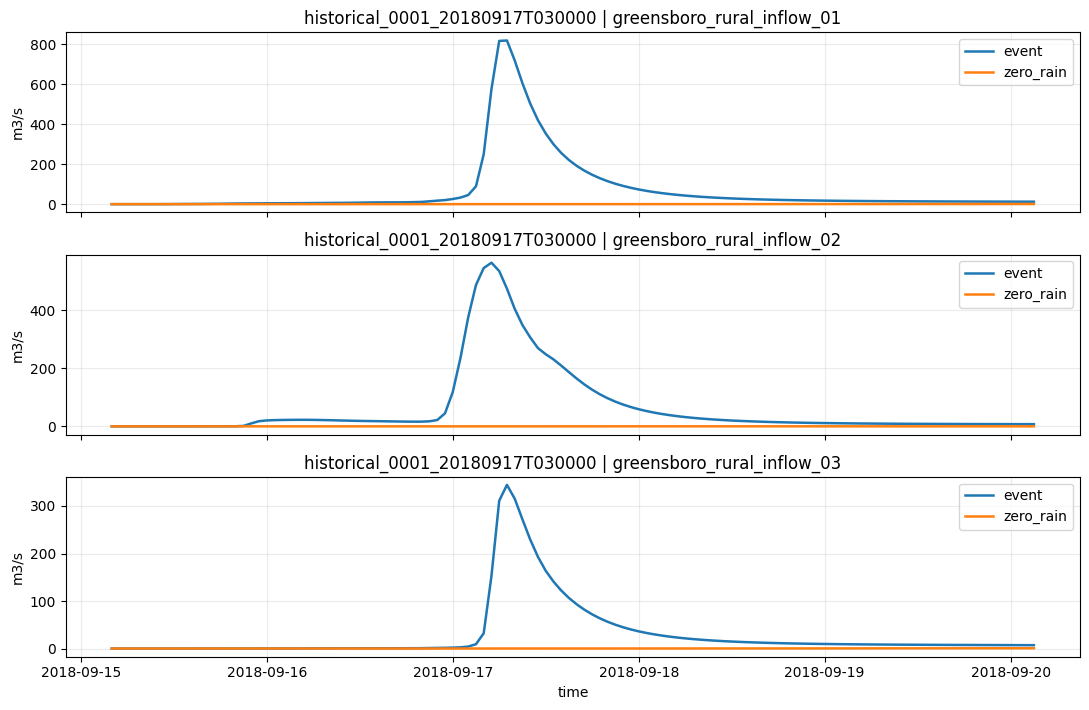

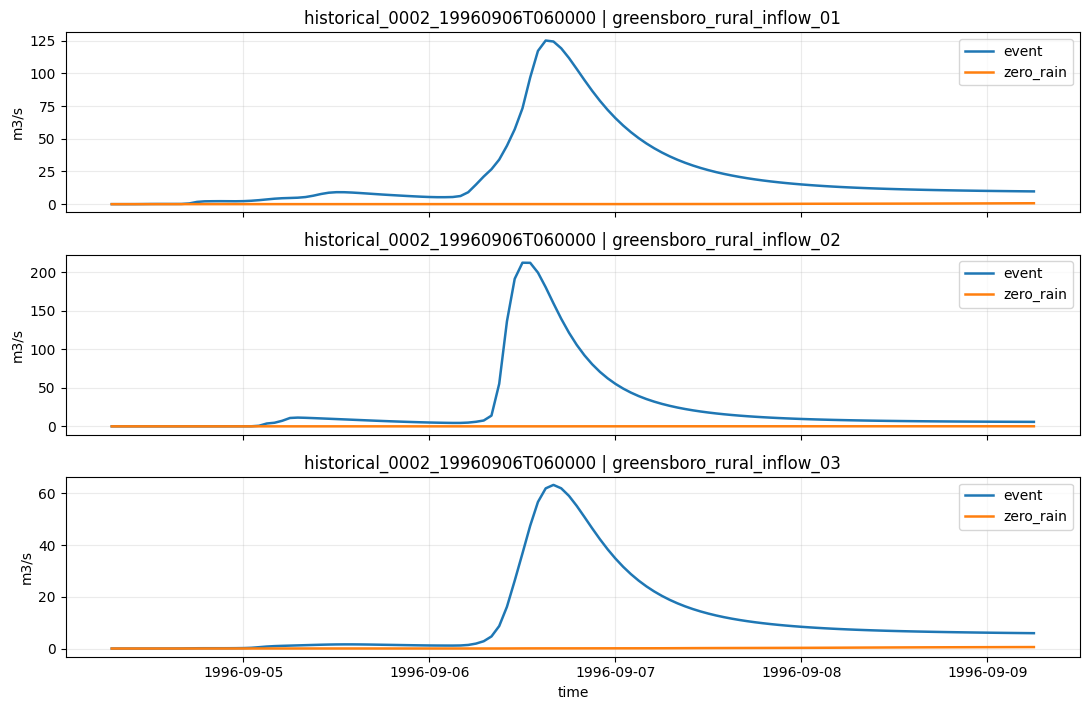

In [13]:
missing_handoff_discharge = []
for event_id in WFLOW_AUDIT_EVENT_IDS:
    handoff_paths = dynamic_handoff_paths(config, location_root, event_id)
    missing = [
        label
        for label, path in {
            "event": handoff_paths["discharge"],
            "zero_rain": handoff_paths["zero_rain_discharge"],
        }.items()
        if not path.exists()
    ]
    if missing:
        missing_handoff_discharge.append({"event_id": event_id, "missing": ",".join(missing)})

missing_handoff_discharge = pd.DataFrame(missing_handoff_discharge)
if not missing_handoff_discharge.empty:
    display(missing_handoff_discharge)
    raise RuntimeError(
        "Historical Wflow validation handoff discharge is missing. "
        "Set EXECUTE_WFLOW_AUDIT=True and rerun the Wflow audit cell; if it is already true, inspect wflow_audit_report."
    )

for event_id in WFLOW_AUDIT_EVENT_IDS:
    plot_handoff_discharge(event_id)


In [14]:
post_run_readout = post_run_handoff_readout(
    config,
    location_root,
    WFLOW_AUDIT_EVENT_IDS,
    streamflow_records_path=streamflow_records_path,
)
post_run_zero_rain_diagnostics = post_run_readout.zero_rain
amplification_readout = post_run_readout.amplification
baseflow_readout = post_run_readout.baseflow

display(post_run_zero_rain_diagnostics)
display(pd.Series({"single_K_amplification": "per-event provenance"}, name="amplification"))
display(amplification_readout)
display(pd.Series({"baseflow_validation": "zero-rain control vs observed low-flow at Primary Reference Gage"}, name="baseflow"))
display(baseflow_readout)


,event_id,event_source_count,zero_rain_source_count,event_total_peak_m3s,zero_rain_total_peak_m3s,zero_over_event_peak_fraction,event_discharge_exists,zero_rain_discharge_exists
0,historical_0001_20180917T030000,3,3,1662.401607,1.393035,0.000838,True,True
1,historical_0002_19960906T060000,3,3,373.418121,1.371972,0.003674,True,True


single_K_amplification    per-event provenance
Name: amplification, dtype: str

,event_id,K,K_status,reference_gage
0,historical_0001_20180917T030000,1.0,no_target,02094500
1,historical_0002_19960906T060000,1.0,no_target,02094500


baseflow_validation    zero-rain control vs observed low-flow at Prim...
Name: baseflow, dtype: str

,event_id,check,sfincs_handoff_id,observed_baseflow_cms,simulated_baseflow_cms,status,message
0,historical_0001_20180917T030000,baseflow,greensboro_rural_inflow_01,0.4864,0.0001,failed,median ref=20.7 cfs; uparea_ratio=0.830; min_f...
1,historical_0001_20180917T030000,baseflow,greensboro_rural_inflow_02,0.4016,0.0001,failed,median ref=20.7 cfs; uparea_ratio=0.685; min_f...
2,historical_0001_20180917T030000,baseflow,greensboro_rural_inflow_03,0.2828,0.0000,failed,median ref=20.7 cfs; uparea_ratio=0.483; min_f...
3,historical_0002_19960906T060000,baseflow,greensboro_rural_inflow_01,0.4864,0.0001,failed,median ref=20.7 cfs; uparea_ratio=0.830; min_f...
4,historical_0002_19960906T060000,baseflow,greensboro_rural_inflow_02,0.4016,0.0001,failed,median ref=20.7 cfs; uparea_ratio=0.685; min_f...
5,historical_0002_19960906T060000,baseflow,greensboro_rural_inflow_03,0.2828,0.0000,failed,median ref=20.7 cfs; uparea_ratio=0.483; min_f...


## Wflow Gauge Output And USGS Comparison

Read Wflow native scalar outputs, map `Q_<index>` columns back to SFINCS and USGS gauge layers, and compare simulated/observed hydrographs where records overlap.


In [15]:
calibration = build_usgs_wflow_calibration(
    config,
    location_root,
    WFLOW_AUDIT_EVENT_IDS,
    events_root=events_root,
    wflow_base_root=wflow_base_root,
    event_streamflow_iv_root=event_streamflow_iv_root,
    active_wflow_submodel_id=ACTIVE_WFLOW_SUBMODEL_ID,
)
calibration_summary = calibration.summary
wflow_calibration_patch = calibration.patch

display(calibration.artifacts)
calibration_summary


calibration_summary_csv    /home/grahamhults/projects/Flood-RM/locations/...
calibration_patch_yaml     /home/grahamhults/projects/Flood-RM/locations/...
calibration_status                                             ready_to_ship
suggested_k_calibration                                             0.737571
validation_event_count                                                     2
Name: wflow_calibration_artifacts, dtype: object

,event_id,site_no,q_column,n,nse,kge,peak_bias_fraction,volume_bias_fraction
0,historical_0001_20180917T030000,02093800,Q_7,120,0.020670,-0.126454,0.973278,0.697415
1,historical_0001_20180917T030000,02093877,Q_8,120,-2.545387,-0.652281,2.378316,0.750260
2,historical_0001_20180917T030000,0209399200,Q_9,120,-3.116571,-1.128186,2.327918,1.084265
3,historical_0001_20180917T030000,02094500,Q_10,120,-4.001886,-0.665370,2.414456,0.601795
4,historical_0001_20180917T030000,02094659,Q_11,120,-0.361676,-0.054472,0.409681,0.855309
5,historical_0001_20180917T030000,02094770,Q_12,120,0.113037,-0.055159,0.904434,0.796112
6,historical_0001_20180917T030000,02094775,Q_13,120,0.504833,0.518515,0.075239,0.398572
7,historical_0001_20180917T030000,02095000,Q_14,120,0.011445,0.018007,1.257380,0.627405
8,historical_0001_20180917T030000,02095181,Q_15,120,-0.346315,0.119481,0.114024,0.691267
9,historical_0001_20180917T030000,02095271,Q_16,120,0.561204,0.666884,-0.072123,0.246676


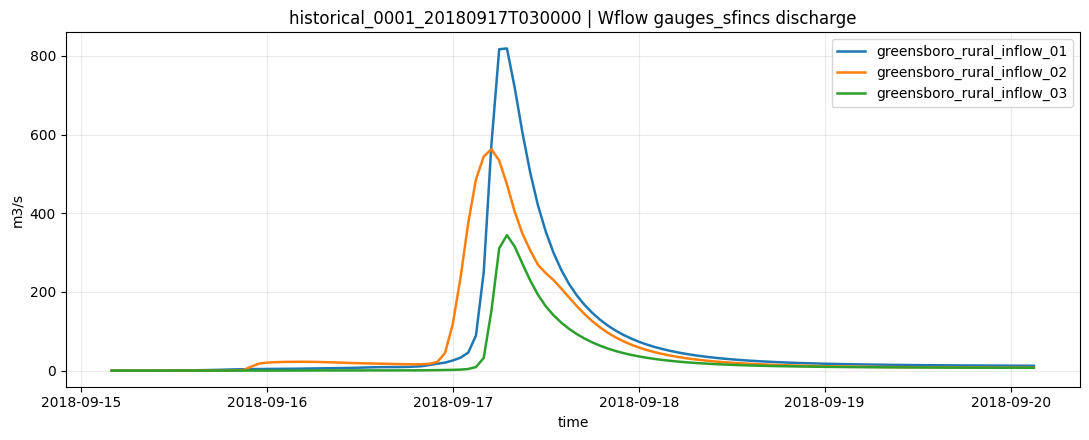

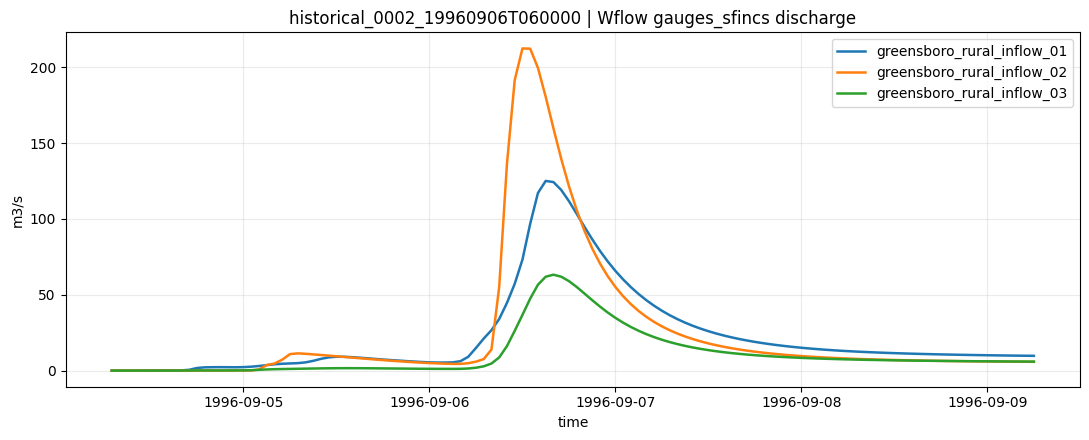

In [16]:
for event_id in WFLOW_AUDIT_EVENT_IDS:
    plot_wflow_sfincs_gauge_output(
        event_id,
        events_root=events_root,
        wflow_base_root=wflow_base_root,
        audit_plots_dir=audit_plots_dir,
        submodel_id=ACTIVE_WFLOW_SUBMODEL_ID,
    )


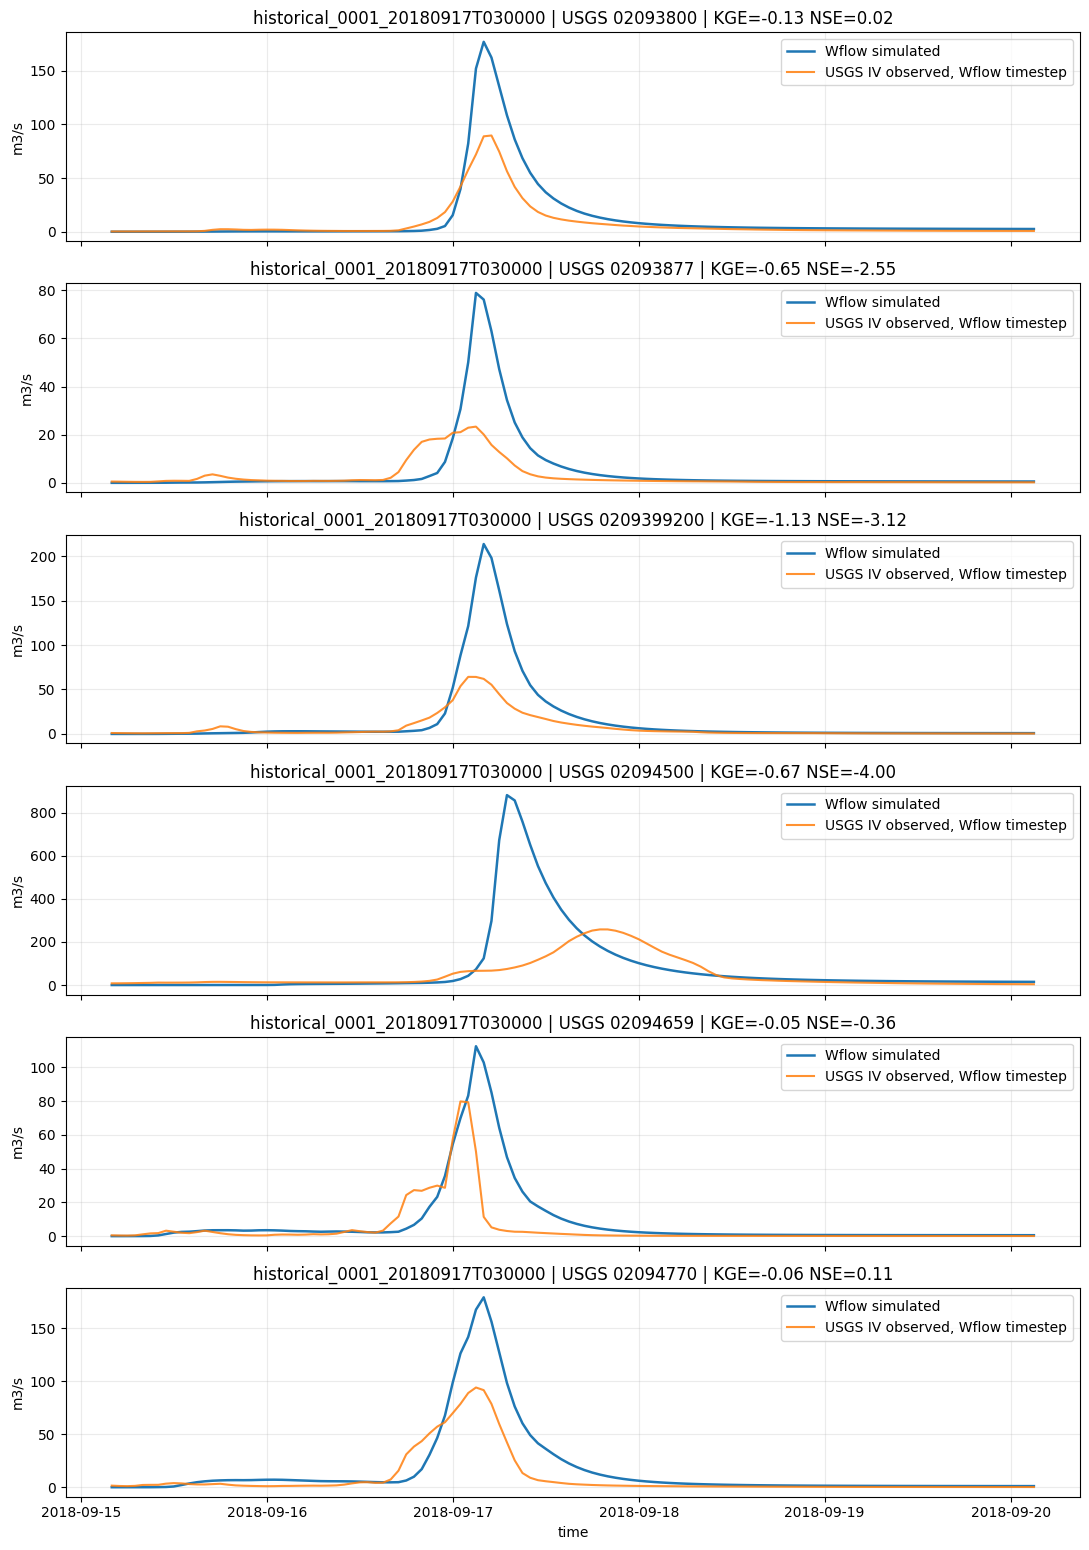

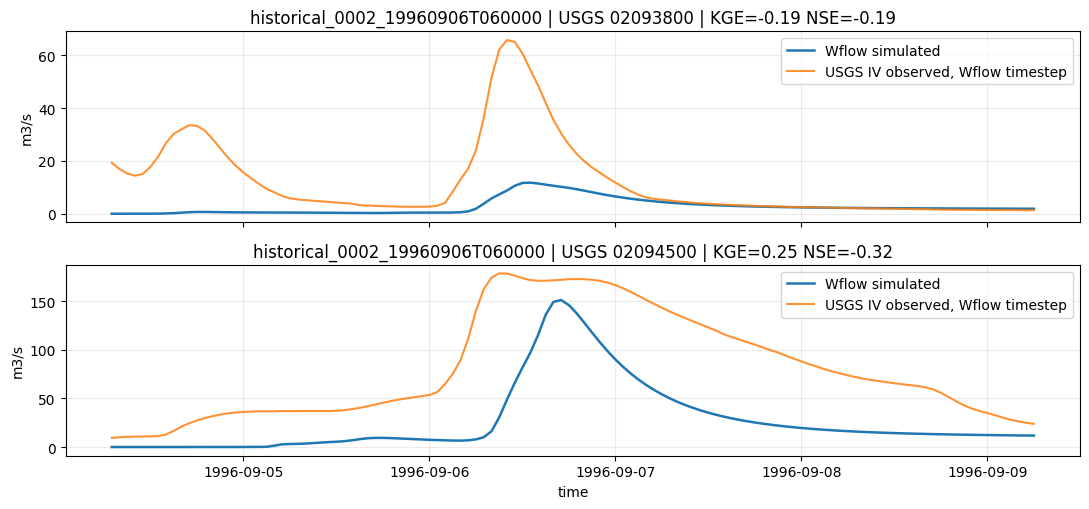

In [17]:
for event_id in WFLOW_AUDIT_EVENT_IDS:
    plot_usgs_observation_comparison(
        event_id,
        events_root=events_root,
        wflow_base_root=wflow_base_root,
        event_streamflow_iv_root=event_streamflow_iv_root,
        audit_plots_dir=audit_plots_dir,
        submodel_id=ACTIVE_WFLOW_SUBMODEL_ID,
    )
